In [ ]:
# ==========================
# Task 1: Data Collection Pipeline
# ==========================

# Import Libraries
import requests
import pandas as pd

# Retrieve Data from GitHub API
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

# Check Status Code
print("Status Code:", response.status_code)

# Convert Response to JSON
data = response.json()

# Explore JSON
print("JSON Keys:", data.keys())
print("Number of Repositories:", len(data["items"]))

# Convert JSON to DataFrame
df = pd.DataFrame(data["items"])

# Explore Dataset
print("\nFirst 5 Rows:")
display(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
display(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

# Select Required Columns
df = df[
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]
]

print("\nSelected Columns:")
display(df.head())

# Extract Owner Name
df["owner"] = df["owner"].apply(
    lambda x: x["login"] if isinstance(x, dict) else None
)

# Extract License Name
df["license"] = df["license"].apply(
    lambda x: x["name"] if isinstance(x, dict) else "No License"
)

# Fill Missing Values
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

print("\nMissing Values After Cleaning:")
display(df.isnull().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)

# Convert Date Columns
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

# Rename Columns
df.rename(columns={
    "name": "repository_name",
    "owner": "owner_name",
    "language": "programming_language",
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date",
    "license": "license_name"
}, inplace=True)

# Final Dataset
print("\nFinal Dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

# Save CSV File
df.to_csv("github_projects.csv", index=False)

print("\nCSV File Saved Successfully!")

# Verify Saved File
github_projects = pd.read_csv("github_projects.csv")

print("\nVerification:")
display(github_projects.head())

print("\nShape:")
print(github_projects.shape)

Status Code: 200
JSON Keys: dict_keys(['total_count', 'incomplete_results', 'items'])
Number of Repositories: 100

First 5 Rows:


,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,75767,2957,196655,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34088,2318,163237,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21753,7,88871,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,52,82190,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15583,20,73834,master,1.0



Shape:
(100, 82)

Columns:


Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null 

...


Shape After Removing Duplicates:
(100, 10)

Final Dataset:


,repository_name,owner_name,programming_language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,196655,75767,196655,2957,2015-11-07 01:19:20+00:00,2026-08-02 07:33:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163237,34088,163237,2318,2018-10-29 13:56:00+00:00,2026-08-02 06:54:41+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88871,21753,88871,7,2021-03-03 01:34:05+00:00,2026-08-02 07:36:25+00:00,MIT License
3,funNLP,fighting41love,Python,82190,15266,82190,52,2018-08-21 11:20:39+00:00,2026-08-02 07:21:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73834,15583,73834,20,2014-07-15 19:11:19+00:00,2026-08-02 07:36:57+00:00,Other



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   repository_name       100 non-null    object             
 1   owner_name            100 non-null    object             
 2   programming_language  100 non-null    object             
 3   stars                 100 non-null    int64              
 4   forks                 100 non-null    int64              
 5   watchers              100 non-null    int64              
 6   open_issues           100 non-null    int64              
 7   created_date          100 non-null    datetime64[ns, UTC]
 8   updated_date          100 non-null    datetime64[ns, UTC]
 9   license_name          100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB

CSV File Saved Successfully!

Verification:

,repository_name,owner_name,programming_language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,196655,75767,196655,2957,2015-11-07 01:19:20+00:00,2026-08-02 07:33:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163237,34088,163237,2318,2018-10-29 13:56:00+00:00,2026-08-02 06:54:41+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88871,21753,88871,7,2021-03-03 01:34:05+00:00,2026-08-02 07:36:25+00:00,MIT License
3,funNLP,fighting41love,Python,82190,15266,82190,52,2018-08-21 11:20:39+00:00,2026-08-02 07:21:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73834,15583,73834,20,2014-07-15 19:11:19+00:00,2026-08-02 07:36:57+00:00,Other



Shape:
(100, 10)


Database Created Successfully!


,repository_name,owner_name,programming_language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,196655,75767,196655,2957,2015-11-07 01:19:20+00:00,2026-08-02 07:33:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163237,34088,163237,2318,2018-10-29 13:56:00+00:00,2026-08-02 06:54:41+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88871,21753,88871,7,2021-03-03 01:34:05+00:00,2026-08-02 07:36:25+00:00,MIT License
3,funNLP,fighting41love,Python,82190,15266,82190,52,2018-08-21 11:20:39+00:00,2026-08-02 07:21:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73834,15583,73834,20,2014-07-15 19:11:19+00:00,2026-08-02 07:36:57+00:00,Other


,repository_name,owner_name,programming_language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,196655,75767,196655,2957,2015-11-07 01:19:20+00:00,2026-08-02 07:33:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163237,34088,163237,2318,2018-10-29 13:56:00+00:00,2026-08-02 06:54:41+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88871,21753,88871,7,2021-03-03 01:34:05+00:00,2026-08-02 07:36:25+00:00,MIT License
3,funNLP,fighting41love,Python,82190,15266,82190,52,2018-08-21 11:20:39+00:00,2026-08-02 07:21:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73834,15583,73834,20,2014-07-15 19:11:19+00:00,2026-08-02 07:36:57+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10475,1618,10475,11,2019-11-24 23:16:28+00:00,2026-08-02 06:46:35+00:00,No License
66,Machine-Learning,Jack-Cherish,Python,10359,5073,10359,7,2017-03-25 07:32:37+00:00,2026-08-02 02:55:46+00:00,No License
67,3D-Machine-Learning,timzhang642,Unknown,10189,1800,10189,21,2017-08-12 15:20:54+00:00,2026-08-01 17:33:10+00:00,No License
68,tpot,EpistasisLab,Jupyter Notebook,10048,1563,10048,310,2015-11-03 21:08:40+00:00,2026-07-31 19:02:10+00:00,GNU Lesser General Public License v3.0


,repository_name,owner_name,programming_language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,73834,15583,73834,20,2014-07-15 19:11:19+00:00,2026-08-02 07:36:57+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,35875,7395,35875,67,2021-01-02 12:08:37+00:00,2026-08-02 07:36:37+00:00,No License
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28845,6153,28845,32,2016-10-09 21:20:25+00:00,2026-08-02 03:09:07+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24722,4191,24722,31,2018-11-01 04:34:19+00:00,2026-08-01 08:56:43+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20814,2589,20814,31,2018-08-15 14:28:41+00:00,2026-08-02 02:02:12+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20233,5471,20233,2,2018-05-09 12:33:08+00:00,2026-08-02 07:40:00+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20014,4233,20014,20,2018-08-04 23:01:00+00:00,2026-08-02 07:37:08+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18058,3971,18058,47,2015-09-12 14:51:38+00:00,2026-08-01 19:07:34+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13834,3081,13834,1,2020-04-17 04:29:23+00:00,2026-08-01 21:37:03+00:00,No License
9,machine-learning-interview,khangich,Unknown,12750,2041,12750,9,2020-08-11 06:26:32+00:00,2026-08-01 05:48:23+00:00,No License


,repository_name,stars
0,tensorflow,196655
1,transformers,163237
2,ML-For-Beginners,88871
3,funNLP,82190
4,awesome-machine-learning,73834
5,scikit-learn,66852
6,gradio,43265
7,500-AI-Machine-learning-Deep-learning-Computer...,35875
8,C-Plus-Plus,34538
9,netron,33293


...

,programming_language,Total_Repositories
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12
4,JavaScript,3
5,Go,3
6,HTML,2
7,C#,2
8,TeX,1
9,Scala,1


,programming_language,Total_Repositories
0,C++,12
1,Jupyter Notebook,19
2,Python,30
3,Unknown,23


,repository_name,stars,programming_language
0,transformers,163237,Python
1,funNLP,82190,Python
2,awesome-machine-learning,73834,Python
3,scikit-learn,66852,Python


,repository_name,programming_language
0,transformers,Python
1,ML-For-Beginners,Jupyter Notebook
2,funNLP,Python
3,awesome-machine-learning,Python
4,scikit-learn,Python
5,gradio,Python
6,ML-From-Scratch,Python
7,linkedin-skill-assessments-quizzes,Python
8,cs249r_book,Python
9,shap,Jupyter Notebook


,repository_name,programming_language
0,tensorflow,C++
1,ML-For-Beginners,Jupyter Notebook
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown
3,C-Plus-Plus,C++
4,netron,JavaScript
...,...,...
65,Machine-Learning-Specialization-Coursera,Jupyter Notebook
66,Learn_Machine_Learning_in_3_Months,Unknown
67,awesome-youtubers,Markdown
68,h2o-3,Jupyter Notebook


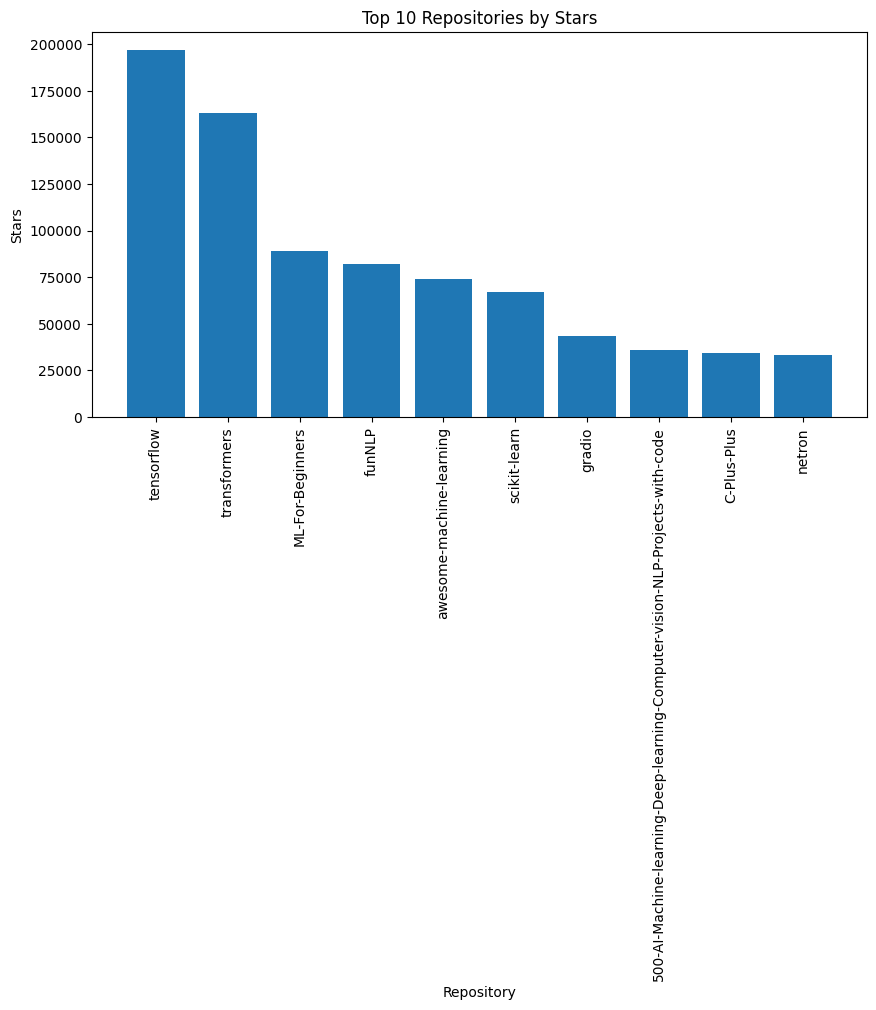

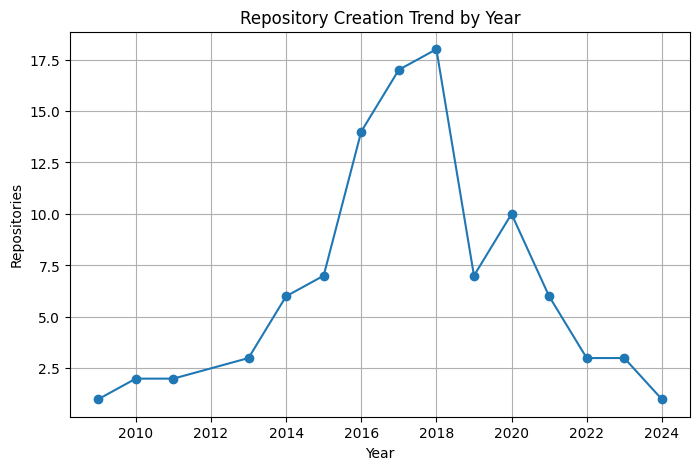

In [ ]:
# ==========================
# TASK 2 - Store and Analyse the Data
# ==========================

# Import Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV File
df = pd.read_csv("github_projects.csv")

# Create SQLite Database
conn = sqlite3.connect("github_projects.db")

# Store Data in Database
df.to_sql("Repositories", conn, if_exists="replace", index=False)

print("Database Created Successfully!")

# Verify Table
query = "SELECT * FROM Repositories LIMIT 5"
display(pd.read_sql(query, conn))

# ==================================
# SQL Query 1
# Repositories with more than 10000 stars
# ==================================

query1 = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""

display(pd.read_sql(query1, conn))

# ==================================
# SQL Query 2
# Repository name contains 'Machine'
# ==================================

query2 = """
SELECT *
FROM Repositories
WHERE repository_name LIKE '%Machine%';
"""

display(pd.read_sql(query2, conn))

# ==================================
# SQL Query 3
# Top 10 repositories by stars
# ==================================

query3 = """
SELECT repository_name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top10 = pd.read_sql(query3, conn)
display(top10)

# ==================================
# SQL Query 4
# Count repositories
# ==================================

query4 = """
SELECT COUNT(*) AS Total_Repositories
FROM Repositories;
"""

display(pd.read_sql(query4, conn))

# ==================================
# SQL Query 5
# Average stars
# ==================================

query5 = """
SELECT AVG(stars) AS Average_Stars
FROM Repositories;
"""

display(pd.read_sql(query5, conn))

# ==================================
# SQL Query 6
# Group by programming language
# ==================================

query6 = """
SELECT programming_language,
COUNT(*) AS Total_Repositories
FROM Repositories
GROUP BY programming_language
ORDER BY Total_Repositories DESC;
"""

language = pd.read_sql(query6, conn)
display(language)

# ==================================
# SQL Query 7
# Languages with more than 5 repositories
# ==================================

query7 = """
SELECT programming_language,
COUNT(*) AS Total_Repositories
FROM Repositories
GROUP BY programming_language
HAVING COUNT(*) > 5;
"""

display(pd.read_sql(query7, conn))

# ==================================
# SQL Query 8
# Using AND
# ==================================

query8 = """
SELECT repository_name, stars, programming_language
FROM Repositories
WHERE stars > 50000
AND programming_language = 'Python';
"""

display(pd.read_sql(query8, conn))

# ==================================
# SQL Query 9
# Using OR
# ==================================

query9 = """
SELECT repository_name, programming_language
FROM Repositories
WHERE programming_language = 'Python'
OR programming_language = 'Jupyter Notebook';
"""

display(pd.read_sql(query9, conn))

# ==================================
# SQL Query 10
# Using NOT
# ==================================

query10 = """
SELECT repository_name, programming_language
FROM Repositories
WHERE NOT programming_language = 'Python';
"""

display(pd.read_sql(query10, conn))

# ==================================
# Visualization 1
# Top 10 Repositories
# ==================================

plt.figure(figsize=(10,5))
plt.bar(top10["repository_name"], top10["stars"])
plt.xticks(rotation=90)
plt.title("Top 10 Repositories by Stars")
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.show()

# ==================================
# Visualization 2
# Repository Creation Trend
# ==================================

df["created_date"] = pd.to_datetime(df["created_date"])

trend = df["created_date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(trend.index, trend.values, marker="o")
plt.title("Repository Creation Trend by Year")
plt.xlabel("Year")
plt.ylabel("Repositories")
plt.grid(True)
plt.show()

# Close Connection
conn.close()